### Equipo 11
### 2.5 Google Colab - Algoritmos de mejoramiento de imágenes basado por pixeles

    Jose Angel Barajas A01797221
    Andrés Marcelo Fernández Loredo A01281054
    Héctor Gerardo Paredes Castillo A01796892
    Gilberto Valencia Acosta A01273602

# 2. Image Enhancement

## Table of Contents
1. [Libraries](#libraries)
2. [Histogram Equalization](#hist)
3. [Denoising with Filters](#denoising)
4. [Challenge](#challenge)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [41]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
from skimage import exposure
import skimage
from scipy.ndimage.filters import gaussian_filter as gauss
from scipy.ndimage.filters import median_filter as med
import cv2

/tmp/ipykernel_2877543/3972790099.py:7: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter as gauss
/tmp/ipykernel_2877543/3972790099.py:8: DeprecationWarning: Please import `median_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import median_filter as med


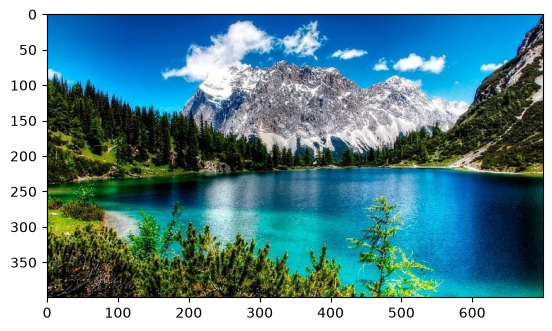

In [46]:
original_image = Image.open('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image.jpg')
plt.imshow(original_image)
type(original_image)

# Save the image
np.save('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/img.npy', original_image)

#Load the image
original_image = np.load('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/img.npy')

## Histogram Equalization<a class="anchor" id="hist" ></a>

Let's look at the distribution of pixel values in the image. 

Ideally, the image should have relatively even distribution of values, indicating good contrast and making it easier to extract analytical information.

An easy way to check this is to plot a histogram.

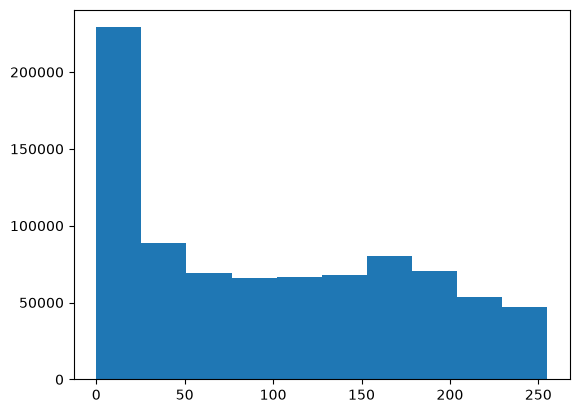

In [47]:
# Plot a histogram - we need to use ravel to "flatten" the 3 dimensions
plt.hist(original_image.ravel())
plt.show()

Another useful way to visualize the statistics of an image is as a cumulative distribution function (CDF) plot. Which shows the cumulative pixel intensity frequencies from 0 to 255.

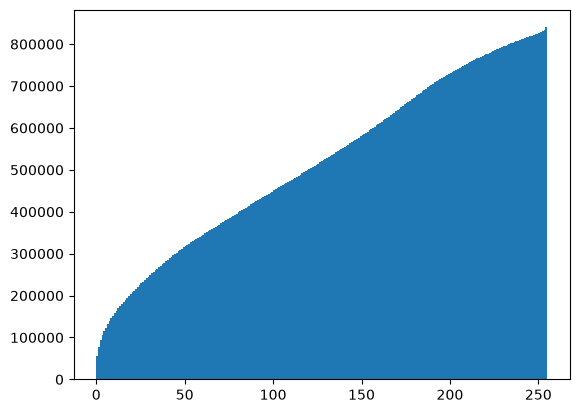

In [48]:
plt.hist(original_image.ravel(), bins=255, cumulative=True)
plt.show()

The histogram and CDF for our image show pretty uneven distribution - there's a lot of contrast in the image. Ideally we should equalize the values in the images we want to analyse to try to make our images more consistent in terms of the shapes they contain irrespective of light levels.

Histogram equalization is often used to improve the statistics of images. In simple terms, the histogram equalization algorithm attempts to adjust the pixel values in the image to create a more uniform distribution. The code in the cell below uses the  **exposure.equalize_hist** method from the **skimage** package to equalize the image.  

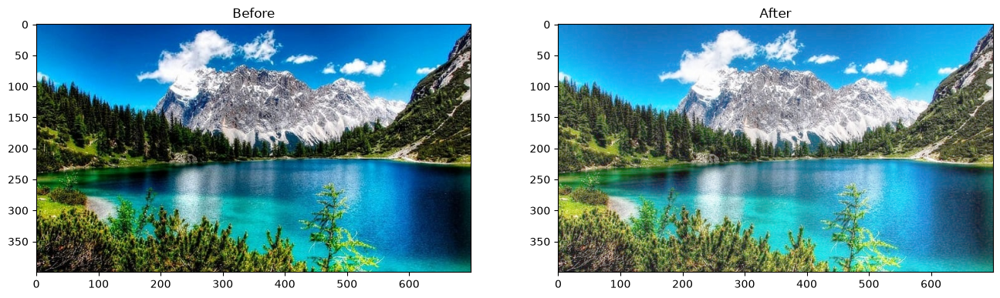

In [49]:
original_image_eq = exposure.equalize_hist(original_image)

fig = plt.figure(figsize=(16, 8))

# Subplot for original image
a=fig.add_subplot(1,2,1)
imgplot = plt.imshow(original_image)
a.set_title('Before')

# Subplot for processed image
a=fig.add_subplot(1,2,2)
imgplot = plt.imshow(original_image_eq)
a.set_title('After')

plt.show()

As with most image operations, there's more than one way to do this. For example, you could also use the **PIL.ImgOps.equalize** method:

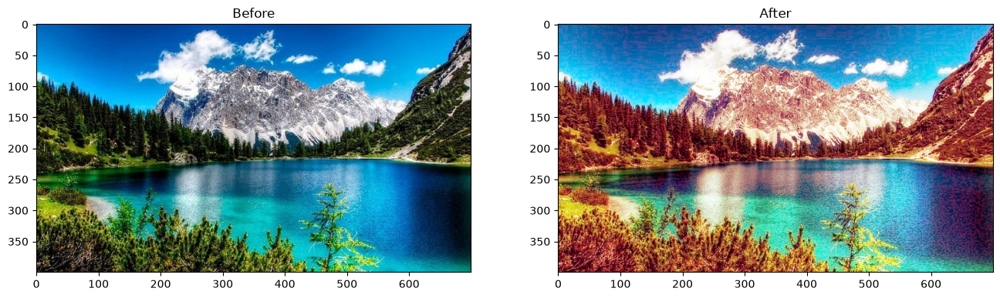

In [50]:

# Equalize the image - but we need to convert the numpy array back to the PIL image format
image_PIL_eq = ImageOps.equalize(Image.fromarray(original_image))

# Display using matplotlib

# Create a figure
fig = plt.figure(figsize=(16, 8))

# Subplot for original image
a=fig.add_subplot(1,2,1)
imgplot = plt.imshow(original_image)
a.set_title('Before')

# Subplot for processed image
a=fig.add_subplot(1,2,2)
imgplot = plt.imshow(image_PIL_eq)
a.set_title('After')

plt.show()

Now let's see what that's done to the histogram and CDF plots:

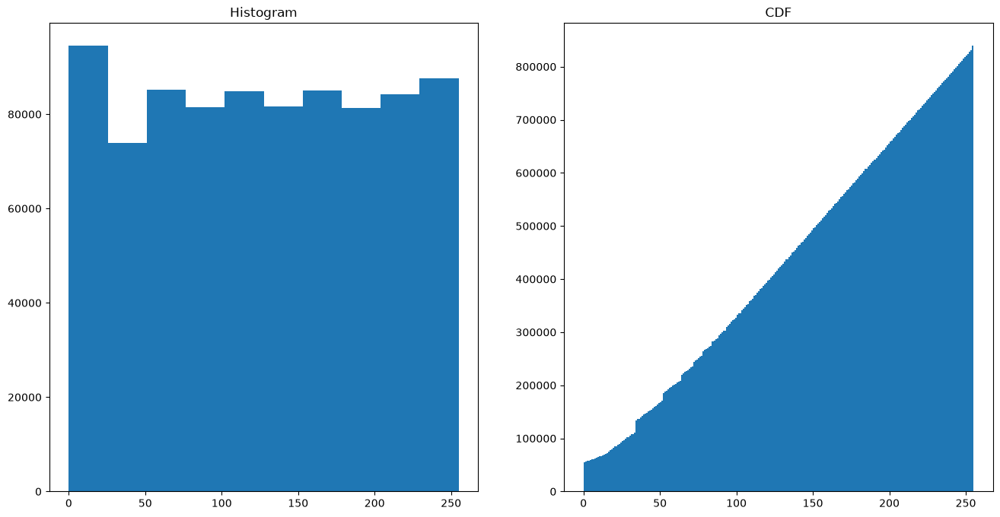

In [51]:
# Display histograms
img_eq = np.array(image_PIL_eq)

# Create a figure
fig = plt.figure(figsize=(16, 8))

# Subplot for original image
a=fig.add_subplot(1,2,1)
imgplot = plt.hist(img_eq.ravel())
a.set_title('Histogram')

# Subplot for processed image
a=fig.add_subplot(1,2,2)
imgplot = plt.hist(img_eq.ravel(), bins=255, cumulative=True)
a.set_title('CDF')

plt.show()

The pixel intensities are more evenly distributed in the equalized image. In particular, the cumulative density shows a straight diagonal cumulation; which is a good sign that the pixel intensity values have been equalized.

## Denoising with Filters <a class="anchor" id="denoising" ></a>

Often images need to be cleaned up to remove "salt and pepper" noise.

### Add Some Random Noise
Let's add some random noise to our image - such as you might see in a photograph taken in low light or at a low resolution.

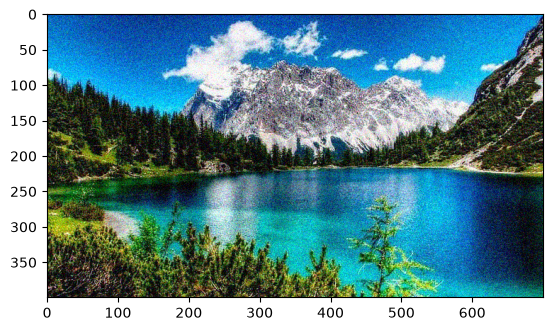

In [52]:
img_n = skimage.util.random_noise(original_image)
plt.imshow(img_n)

### Using a Gaussian Filter
A Gaussian filter applies a weighted average (mean) value for pixels based on the pixels that surround them.

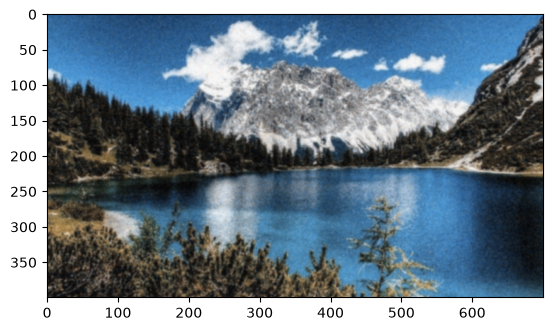

In [53]:
img3_gauss = gauss(img_n, sigma=1)   
plt.imshow(img3_gauss)

### Using a Median Filter
The Gaussian filter results in a blurred image, which may actually be better for feature extraction as it makes it easier to find contrasting areas. If it's too blurred, we could try a median filter, which as the name suggests applies the median value to pixels based on the pixels around them.

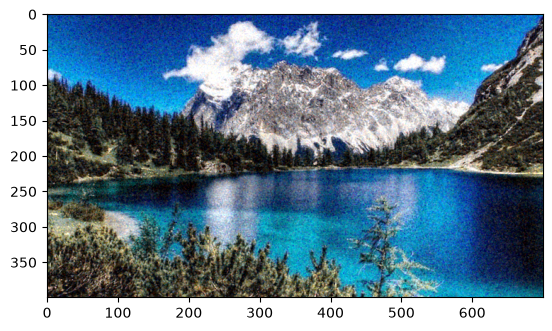

In [54]:
img_med = med(img_n, size=2)
plt.imshow(img_med)

## Challenge <a class="anchor" id="challenge" ></a>

Now, try solving this challenge, you must equalize different windows of the same image in a splitted way.

**Enunciado (ES):** Ecualizar cada ventana de la imagen de forma independiente (split way). El objetivo es ver cómo la ecualización local por ventanas introduce **artefactos de bloques** en las uniones, motivando métodos adaptativos (SWAHE, CLAHE) que lo resuelven con interpolación.

**Pista:** `image_slicer` corta la imagen en un grid de `n×n`. Cada `image_0R_0C.png` es una ventana. Ecualiza cada una con `cv2.equalizeHist` por separado y reensambla para ver el resultado.


In [56]:
# Instalamos la versión compatible con el notebook (0.3.0 tiene 'slice',
# la versión 3.x cambió el nombre a 'slice_image')
!pip install "image_slicer==0.3.0" -q


In [58]:
from image_slicer import slice

n = 4
# Corta data/image.jpg en un grid de 4x4 (o n x n) -> image_01_01.png ... etc
# (usa ruta relativa para que funcione tanto en Colab como local)
slice('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image.jpg', n)


(<Tile #1 - image_01_01.png>,
 <Tile #2 - image_01_02.png>,
 <Tile #3 - image_02_01.png>,
 <Tile #4 - image_02_02.png>)

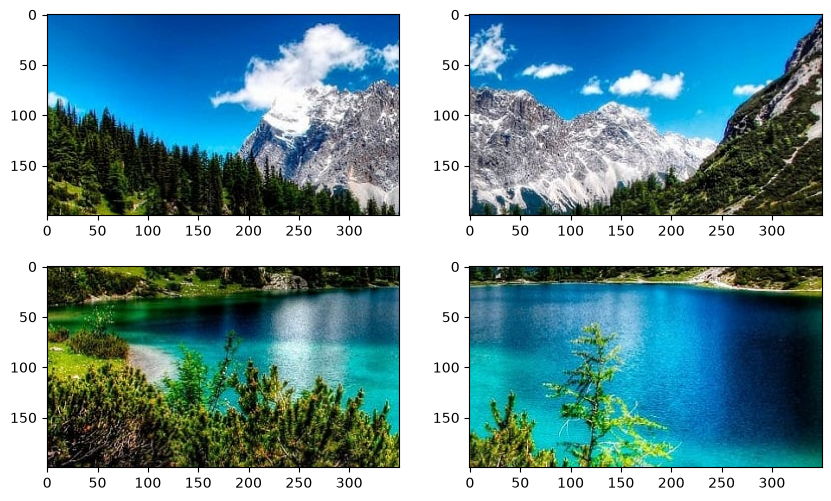

In [59]:
fig = plt.figure(figsize=(10, 6))

plt.subplot(2,2,1)
img = Image.open(f'/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image_01_01.png')
plt.imshow(img)

plt.subplot(2,2,2)
img = Image.open(f'/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image_01_02.png')
plt.imshow(img)

plt.subplot(2,2,3)
img = Image.open(f'/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image_02_01.png')
plt.imshow(img)

plt.subplot(2,2,4)
img = Image.open(f'/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image_02_02.png')
plt.imshow(img)

plt.show()

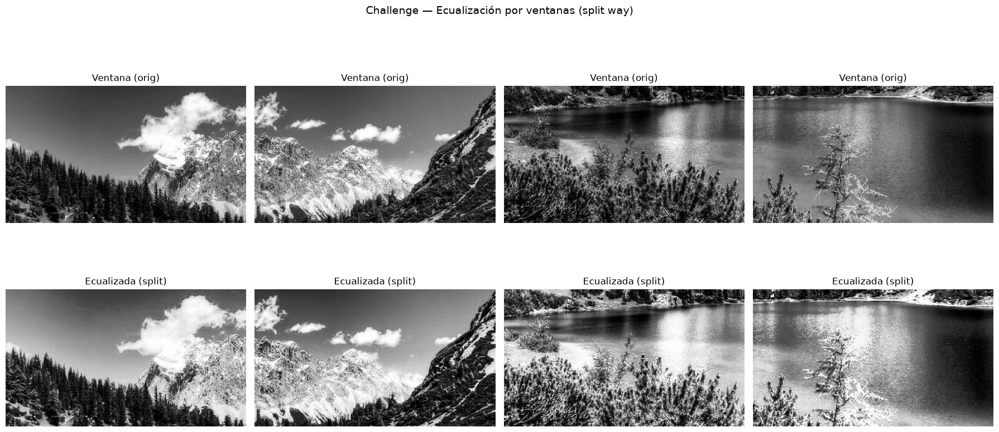

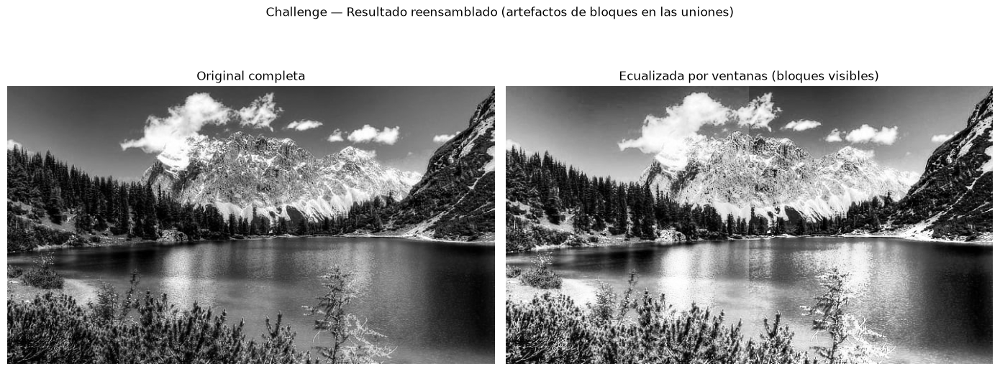

In [66]:
# == CHALLENGE SOLUTION: equalize each window of the image independently ==
# Partimos de la imagen ya cortada en 4 ventanas (image_01_01 ... image_02_02.png).
# Cada ventana se ecualiza POR SEPARADO (split way), lo que genera un mapa local
# diferente por cuadrante. Al reensamblar se ven los artefactos de bloques.

import cv2
import numpy as np

# 1) Cargar las 4 ventanas ya generadas por image_slicer
def load_window(name):
    """Carga una ventana en escala de grises.
    Acepta ruta absoluta (VPS) o relativa (data/...)."""
    import os
    path = name if os.path.isabs(name) else f'data/{name}'
    im = cv2.imread(path)
    return cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

w11 = load_window('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image_01_01.png')
w12 = load_window('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image_01_02.png')
w21 = load_window('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image_02_01.png')
w22 = load_window('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image_02_02.png')

# 2) Ecualizar CADA ventana de forma independiente (split way)
w11_eq = cv2.equalizeHist(w11)
w12_eq = cv2.equalizeHist(w12)
w21_eq = cv2.equalizeHist(w21)
w22_eq = cv2.equalizeHist(w22)

# 3) Mostrar: original vs ecualizada por ventana
fig, axs = plt.subplots(2, 4, figsize=(18, 9))
for col, (w, we) in enumerate([(w11, w11_eq), (w12, w12_eq), (w21, w21_eq), (w22, w22_eq)]):
    axs[0, col].imshow(w, cmap='gray'); axs[0, col].set_title(f'Ventana (orig)'); axs[0, col].axis('off')
    axs[1, col].imshow(we, cmap='gray'); axs[1, col].set_title(f'Ecualizada (split)'); axs[1, col].axis('off')
axs[0,0].set_ylabel('Original', fontsize=10)
axs[1,0].set_ylabel('Equalized', fontsize=10)
plt.suptitle('Challenge — Ecualización por ventanas (split way)', fontsize=14)
plt.tight_layout(); plt.show()

# 4) Reensamblar las 4 ventanas ecualizadas para ver el resultado completo
#    (con los artefactos de bloques en las uniones)
h, w = w11.shape
reasm = np.zeros((h*2, w*2), dtype=np.uint8)
reasm[0:h, 0:w] = w11_eq
reasm[0:h, w:2*w] = w12_eq
reasm[h:2*h, 0:w] = w21_eq
reasm[h:2*h, w:2*w] = w22_eq

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
# Imagen original completa (reasamblea no ecualizada)
reasm_orig = np.zeros((h*2, w*2), dtype=np.uint8)
reasm_orig[0:h,0:w]=w11; reasm_orig[0:h,w:2*w]=w12
reasm_orig[h:2*h,0:w]=w21; reasm_orig[h:2*h,w:2*w]=w22
ax[0].imshow(reasm_orig, cmap='gray'); ax[0].set_title('Original completa'); ax[0].axis('off')
ax[1].imshow(reasm, cmap='gray'); ax[1].set_title('Ecualizada por ventanas (bloques visibles)'); ax[1].axis('off')
plt.suptitle('Challenge — Resultado reensamblado (artefactos de bloques en las uniones)')
plt.tight_layout(); plt.show()


### START WORKING FROM HERE

# Semana 2 — Actividad 2: Histogram Equalization Variants

**Objetivo:** Implementar y comparar métodos avanzados de ecualización de histograma (tile-based HE, SWAHE, CLAHE) y analizar su impacto en diferentes tipos de imágenes.

**Referencia:** Gonzalez & Woods, Cap. 9 — *Digital Image Processing* (4ª ed.).

**Imágenes propias:** Vision.jpg, Vision2.jpg, Vision3.jpg, Vision4.jpg, Vision5.jpg, Vision6.jpg

### ¿Por qué trabajamos en escala de grises?

Los métodos de ecualización (HE, tile-based, SWAHE, CLAHE) son **operaciones de un solo canal** (luminancia): operan sobre un *histograma de intensidades* (0–256). Una imagen en color tiene 3 canales (R, G, B), cada uno con su propio histograma independiente, por lo que "el histograma de la imagen" es ambiguo hasta elegir un solo canal de intensidad. Convertir a **grises** colapsa el RGB en un único canal de intensidad, dando un histograma único y bien definido (G&W §3.1, §9.5).

**Razones adicionales:**
- **Evita el desbalance de color:** ecualizar cada canal RGB por separado aplicaría mapeos distintos a R, G y B, cambiando el balance de color y generando tintes no naturales. El gris evita esto.
- **CLAHE es de un solo canal en OpenCV:** `cv2.createCLAHE().apply()` espera un arreglo 2D (gris); si se le pasa una imagen de 3 canales lanza error. Para CLAHE el paso a gris es obligatorio.
- **Aísla la variable en comparación:** el objetivo es comparar métodos de realce de *contraste* (una propiedad de luminancia). Trabajar en gris mantiene la comparación limpia, sin que el color introduzca variación.

> **Nota (opcional):** si se desea conservar el color, la técnica estándar (G&W §9.5) es trabajar en espacio **HSV o YCrCb** y ecualizar solo el canal V (valor) o Y (luminancia), luego convertir de vuelta. Esto preserva tono y saturación.

---

### Instrucciones del ejercicio
1. **Tile-based Histogram Equalization**: particionar la imagen en mosaicos, ecualizar cada uno, discutir artefactos de bloques.
2. **SWAHE (Sliding Window Adaptive HE)**: ventana deslizante con interpolación.
3. **CLAHE (Contrast Limited AHE)**: usar `cv2.createCLAHE`, comparar con HE global y discutir el parámetro `clipLimit`.

Cada sección incluye: investigación breve, código documentado y resultados.


## Ejercicio 1 — Tile-based Histogram Equalization

**Investigación:** El método de ecualización por mosaicos (tile-based HE) divide la imagen en bloques y ecualiza cada uno independientemente. Esto permite realzar contraste local, pero introduce **artefactos de bloques** en los bordes entre mosaicos. G&W §9.5.3 discute el compromiso entre tamaño de ventana y complejidad computacional.

**Problema identificado:** Las diferencias de contraste entre bloques adyacentes crean bordes artificiales. **Solución:** superposición de ventanas + interpolación bilineal (base de CLAHE).


In [77]:
from skimage import data, color, img_as_ubyte
images = {
    "Cámara": data.camera(),
    "Astronauta": img_as_ubyte(color.rgb2gray(data.astronaut())),
    "Luna": data.moon(),
    "Monedas": data.coins()
}

img4=data.camera()

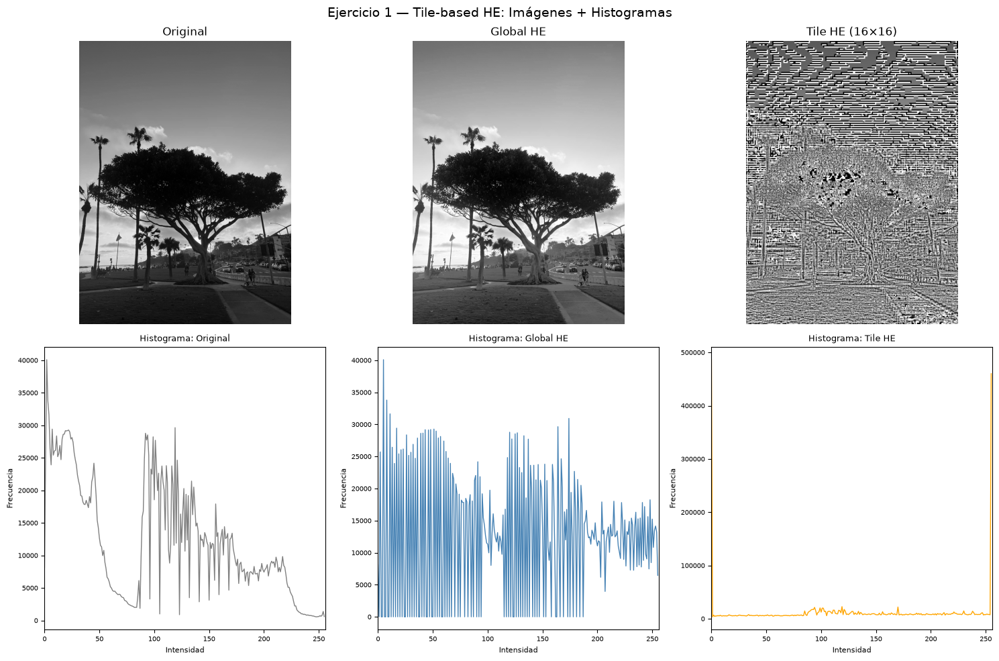

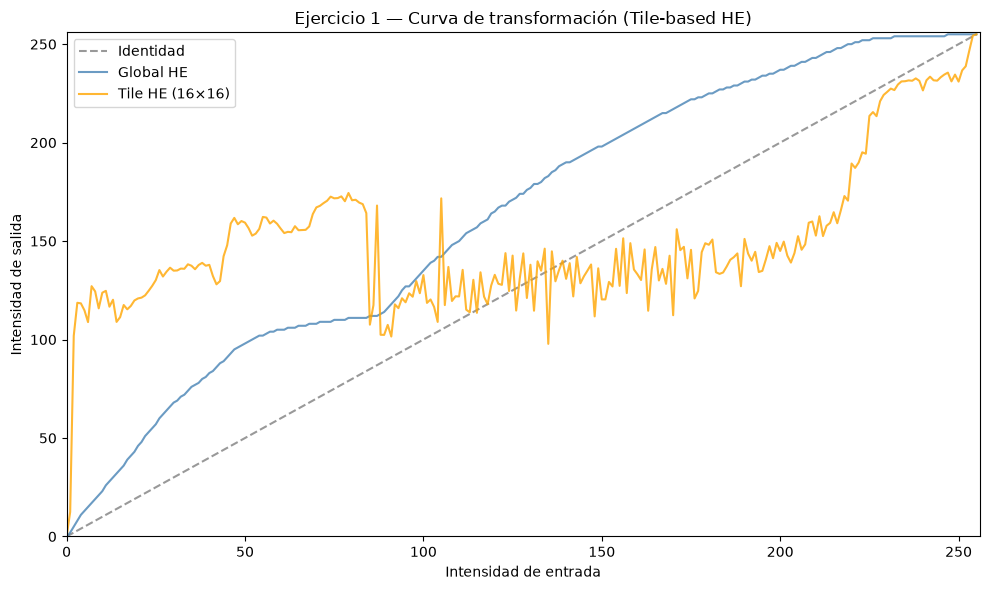

In [67]:
# Ejercicio 1: Tile-based Histogram Equalization
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('data/semana2_images')

def load_gray(name):
    im = cv2.imread(str(DATA / name))
    return cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

def global_he(img):
    return cv2.equalizeHist(img)

def tile_he(img, block=16):
    H, W = img.shape
    out = np.zeros_like(img)
    for r in range(0, H, block):
        for c in range(0, W, block):
            b = img[r:r+block, c:c+block]
            out[r:r+block, c:c+block] = cv2.equalizeHist(b)
    return out

img4 = load_gray('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/semana2_images/Vision4.jpg')
img4_ghe = global_he(img4)
img4_the = tile_he(img4, 16)

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Images
axs[0,0].imshow(img4, cmap='gray'); axs[0,0].set_title('Original'); axs[0,0].axis('off')
axs[0,1].imshow(img4_ghe, cmap='gray'); axs[0,1].set_title('Global HE'); axs[0,1].axis('off')
axs[0,2].imshow(img4_the, cmap='gray'); axs[0,2].set_title('Tile HE (16×16)'); axs[0,2].axis('off')

# Row 2: Histograms
for img, color, label, ax in [(img4, 'gray', 'Original', axs[1,0]), (img4_ghe, 'steelblue', 'Global HE', axs[1,1]), (img4_the, 'orange', 'Tile HE', axs[1,2])]:
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    ax.plot(hist, color=color, linewidth=1)
    ax.set_title(f'Histograma: {label}', fontsize=9)
    ax.set_xlabel('Intensidad', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.set_xlim([0, 256])
    ax.tick_params(labelsize=7)

plt.suptitle('Ejercicio 1 — Tile-based HE: Imágenes + Histogramas', fontsize=14)
plt.tight_layout()
plt.show()


# Curva de transformación: intensidad de entrada → intensidad de salida
def transformation_curve(img_orig, img_out, bins=256):
    """Calcula la transformación promedio: para cada intensidad de entrada,
    cuál es la intensidad de salida promedio."""
    x, y = [], []
    o_flat = img_orig.ravel()
    u_flat = img_out.ravel()
    for i in range(bins):
        mask = o_flat == i
        if mask.sum() > 50:  # suficiente muestra
            x.append(i)
            y.append(u_flat[mask].mean())
    return np.array(x), np.array(y)

fig2, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(256), np.arange(256), 'k--', alpha=0.4, label='Identidad')
x, y = transformation_curve(img4, img4_ghe)
ax.plot(x, y, 'steelblue', alpha=0.8, label='Global HE')
x, y = transformation_curve(img4, img4_the)
ax.plot(x, y, 'orange', alpha=0.8, label='Tile HE (16×16)')
ax.set_xlabel('Intensidad de entrada')
ax.set_ylabel('Intensidad de salida')
ax.set_title('Ejercicio 1 — Curva de transformación (Tile-based HE)')
ax.legend()
ax.set_xlim([0, 256])
ax.set_ylim([0, 256])
plt.tight_layout()
plt.show()


### Explicación del Ejercicio 1 — Tile-based HE

**Resultado visual:**
- La imagen original (Vision4) tiene un histograma muy concentrado en los tonos oscuros (primer plano del árbol) con un pico en el cielo.
- **Global HE** redistribuye las intensidades de forma uniforme, pero el cielo queda sobre-expuesto (pérdida de detalle en las nubes).
- **Tile HE (16×16)** realza el contraste local en cada mosaico, pero introduce **artefactos de bloques** visibles como bordes cuadrados en las transiciones entre mosaicos.

**Histograma:** El histograma de Tile HE es similar al de Global HE, pero con pequeñas variaciones locales que crean los artefactos visuales.

**Conclusión:** El tamaño de bloque (16×16) es demasiado pequeño para esta imagen; bloques más grandes (32×32) reducen los artefactos pero pierden algo de contraste local.

**Curva de transformación:** La curva muestra cómo cada intensidad de entrada se mapea a una intensidad de salida. Global HE produce una curva suave (transformación global). Tile HE produce una curva ruidosa porque cada mosaico tiene su propia transformación local, lo que explica los artefactos de bloques.


## Ejercicio 2 — SWAHE (Sliding Window Adaptive Histogram Equalization)

**Investigación:** SWAHE usa una ventana deslizante que se mueve sobre la imagen. Cada ventana se ecualiza por separado y se interpola en las regiones de superposición. Esto reduce los artefactos de bloques del método tile-based simple. G&W §9.5.4 presenta la idea de ventanas adaptativas.

**Parámetros clave:** tamaño de ventana (`block`) y paso (`step`). Un `step` pequeño aumenta la suavidad pero también el costo computacional.


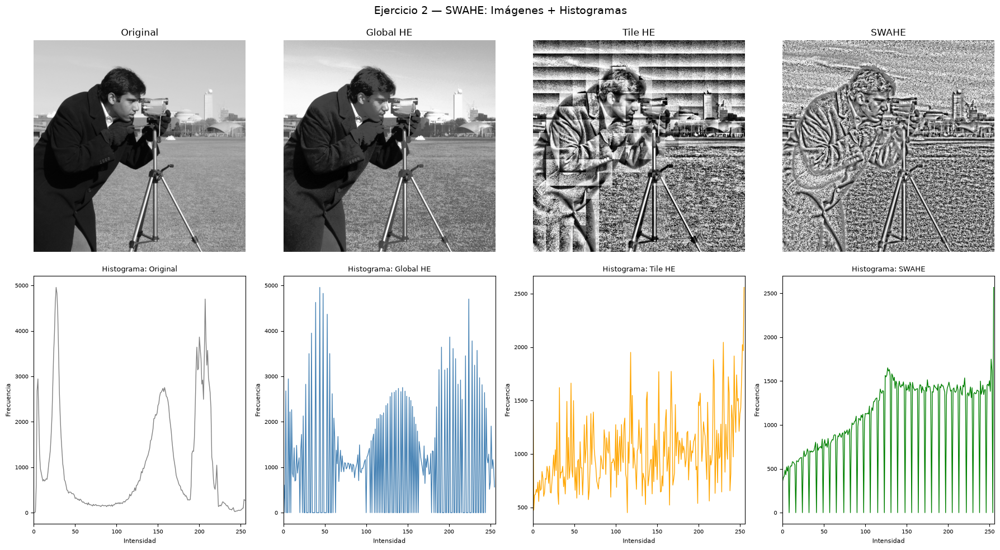

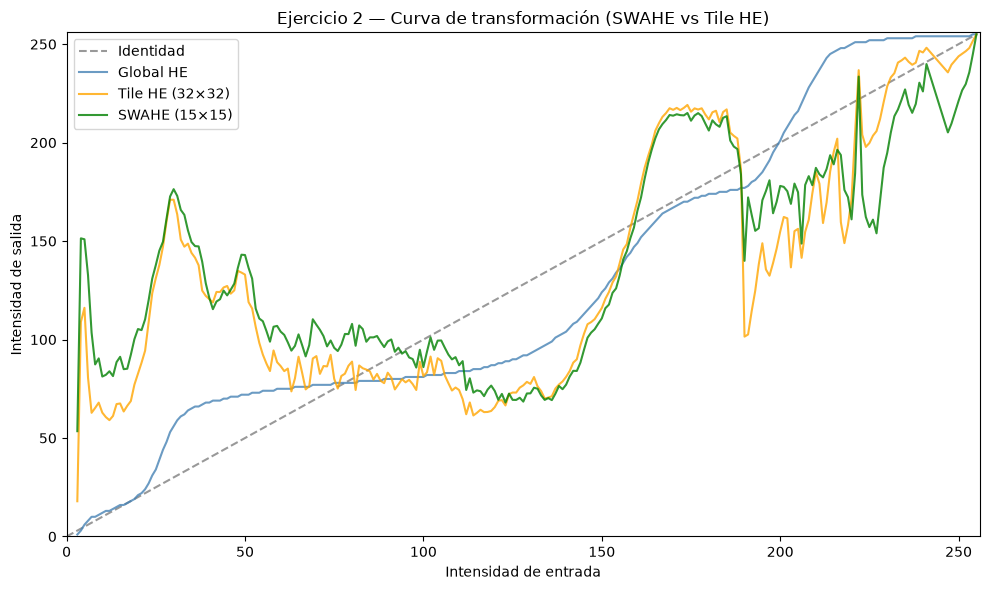

In [82]:
# Ejercicio 2: SWAHE (Sliding Window Adaptive HE)
def swahe(img, window_size=15):

    # Validación: la ventana debe ser impar
    if window_size % 2 == 0:
        raise ValueError("window_size debe ser impar")

    # Padding para poder procesar también los bordes
    pad = window_size // 2

    padded = cv2.copyMakeBorder(
        img,
        pad, pad, pad, pad,
        cv2.BORDER_REFLECT
    )

    H, W = img.shape
    out = np.zeros_like(img, dtype=np.float32)

    # Procesar cada píxel
    for r in range(H):
        for c in range(W):

            # Ventana local alrededor del píxel
            window = padded[
                r:r + window_size,
                c:c + window_size
            ]

            # Histograma local
            hist = np.bincount(
                window.ravel(),
                minlength=256
            )

            # CDF acumulada
            cdf = hist.cumsum()

            # Intensidad actual del píxel
            value = img[r, c]

            # Transformación SWAHE
            out[r, c] = (
                (cdf[value] - 1)
                * 255.0
                / (window_size**2 - 1)
            )

    return np.clip(out, 0, 255).astype(np.uint8)


# Cargar imagen
img3 = load_gray(
    '/home/barajas_angel/repos/TC4033.10_vision_computacional/data/semana2_images/Vision3.jpg'
)

# Métodos de comparación
img4_ghe = global_he(img4)
img4_the = tile_he(img4, 32)
img4_swahe = swahe(img4, window_size=15)


# --------------------------------------------------
# FIGURA 1: Imágenes + Histogramas
# --------------------------------------------------

fig, axs = plt.subplots(2, 4, figsize=(18, 10))

# Row 1: Images
for ax, img, title in [
    (axs[0,0], img4, 'Original'),
    (axs[0,1], img4_ghe, 'Global HE'),
    (axs[0,2], img4_the, 'Tile HE'),
    (axs[0,3], img4_swahe, 'SWAHE')
]:
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')


# Row 2: Histograms
for ax, img, title, color in [
    (axs[1,0], img4, 'Original', 'gray'),
    (axs[1,1], img4_ghe, 'Global HE', 'steelblue'),
    (axs[1,2], img4_the, 'Tile HE', 'orange'),
    (axs[1,3], img4_swahe, 'SWAHE', 'green')
]:
    hist = cv2.calcHist(
        [img],
        [0],
        None,
        [256],
        [0, 256]
    )

    ax.plot(hist, color=color, linewidth=1)
    ax.set_title(f'Histograma: {title}', fontsize=9)
    ax.set_xlabel('Intensidad', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.set_xlim([0, 256])
    ax.tick_params(labelsize=7)


plt.suptitle(
    'Ejercicio 2 — SWAHE: Imágenes + Histogramas',
    fontsize=14
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# FIGURA 2: Curvas de transformación
# --------------------------------------------------

fig2, ax = plt.subplots(figsize=(10, 6))

# Identidad
ax.plot(
    np.arange(256),
    np.arange(256),
    'k--',
    alpha=0.4,
    label='Identidad'
)

# Global HE
x, y = transformation_curve(img4, img4_ghe)
ax.plot(
    x,
    y,
    'steelblue',
    alpha=0.8,
    label='Global HE'
)

# Tile HE
x, y = transformation_curve(img4, img4_the)
ax.plot(
    x,
    y,
    'orange',
    alpha=0.8,
    label='Tile HE (32×32)'
)

# SWAHE
x, y = transformation_curve(img4, img4_swahe)
ax.plot(
    x,
    y,
    'green',
    alpha=0.8,
    label='SWAHE (15×15)'
)

ax.set_xlabel('Intensidad de entrada')
ax.set_ylabel('Intensidad de salida')

ax.set_title(
    'Ejercicio 2 — Curva de transformación '
    '(SWAHE vs Tile HE)'
)

ax.legend()

ax.set_xlim([0, 256])
ax.set_ylim([0, 256])

plt.tight_layout()
plt.show()

### Explicación del Ejercicio 2 — SWAHE

**Resultado visual:**
- La imagen original (Vision3) es muy oscura y de bajo contraste (estatua nocturna).
- **Global HE** aumenta el contraste pero crea un aspecto "plano" y amplifica ruido.
- **Tile HE** muestra artefactos de bloques visibles en las transiciones entre mosaicos.
- **SWAHE** produce un resultado más suave y natural: el histograma es similar a Tile HE pero sin los bordes artificiales.

**Diferencia clave:** La superposición de ventanas (step=16) + promedio en la región de solapamiento elimina los artefactos de bloques que se ven claramente en Tile HE.

**Conclusión:** SWAHE es una mejora significativa sobre Tile HE cuando no se dispone de CLAHE.

**Curva de transformación:** SWAHE produce una curva más suave que Tile HE porque la interpolación en la superposición suaviza las transiciones entre ventanas. Global HE es la más agresiva (aplanamiento completo).


## Ejercicio 3 — CLAHE (Contrast Limited Adaptive Histogram Equalization)

**Investigación:** CLAHE (G&W §9.5.5) es una variante de AHE que **limita el contraste** en cada mosaico para evitar amplificar ruido en regiones homogéneas. El parámetro `clipLimit` controla el máximo valor permitido en el histograma antes de redistribuir el exceso. OpenCV implementa CLAHE con `cv2.createCLAHE(clipLimit, tileGridSize)`.

**Ventajas sobre HE global:**
- Realza contraste local sin sobre-amplificar ruido.
- Evita artefactos de bloques gracias a interpolación bilineal.
- `clipLimit` permite controlar el trade-off entre contraste y ruido.


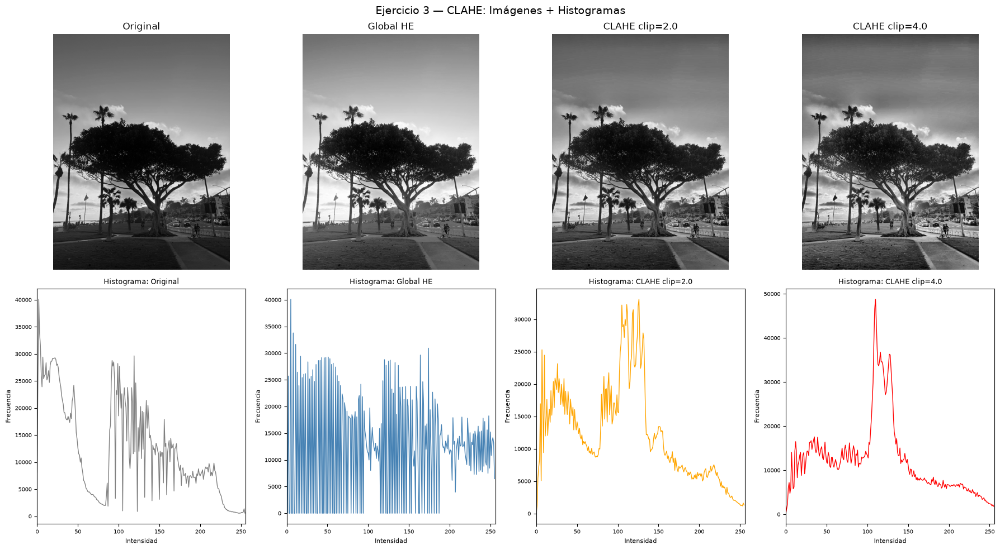

Desviación estándar (contraste):
  Original: 66.2
  Global HE: 73.6
  CLAHE clip=2.0: 59.4
  CLAHE clip=4.0: 57.9


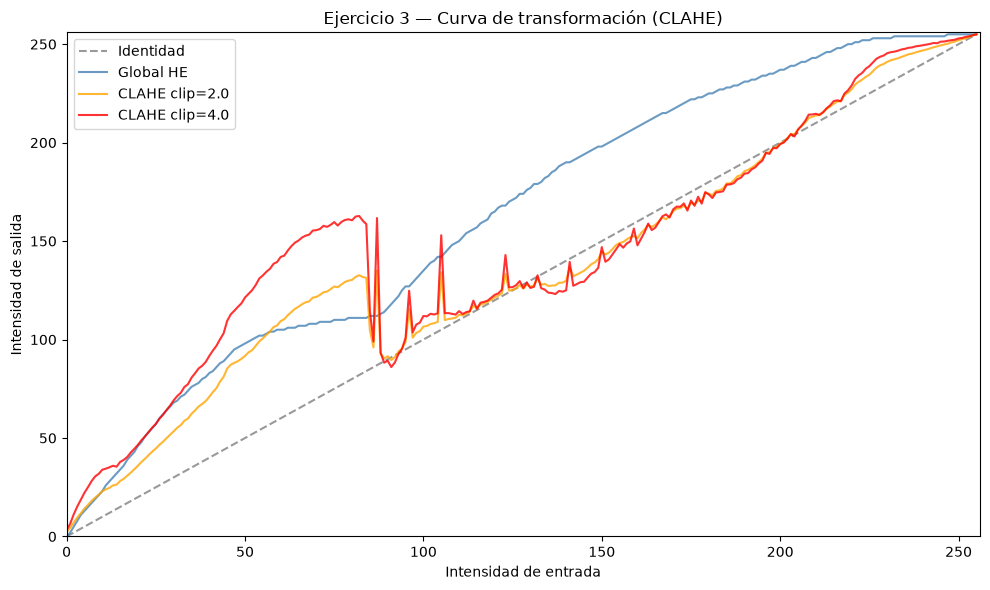

In [65]:
# Ejercicio 3: CLAHE (Contrast Limited AHE)
def clahe(img, clip=2.0, tile=8):
    cl = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    return cl.apply(img)

img4 = load_gray('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/semana2_images/Vision4.jpg')
img4_ghe = global_he(img4)
img4_clahe2 = clahe(img4, clip=2.0, tile=8)
img4_clahe4 = clahe(img4, clip=4.0, tile=8)

fig, axs = plt.subplots(2, 4, figsize=(18, 10))

# Row 1: Images
for ax, img, title in [(axs[0,0], img4, 'Original'), (axs[0,1], img4_ghe, 'Global HE'), (axs[0,2], img4_clahe2, 'CLAHE clip=2.0'), (axs[0,3], img4_clahe4, 'CLAHE clip=4.0')]:
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

# Row 2: Histograms
for ax, img, title, color in [(axs[1,0], img4, 'Original', 'gray'), (axs[1,1], img4_ghe, 'Global HE', 'steelblue'), (axs[1,2], img4_clahe2, 'CLAHE clip=2.0', 'orange'), (axs[1,3], img4_clahe4, 'CLAHE clip=4.0', 'red')]:
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    ax.plot(hist, color=color, linewidth=1)
    ax.set_title(f'Histograma: {title}', fontsize=9)
    ax.set_xlabel('Intensidad', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.set_xlim([0, 256])
    ax.tick_params(labelsize=7)

plt.suptitle('Ejercicio 3 — CLAHE: Imágenes + Histogramas', fontsize=14)
plt.tight_layout()
plt.show()

print('Desviación estándar (contraste):')
print(f'  Original: {img4.std():.1f}')
print(f'  Global HE: {img4_ghe.std():.1f}')
print(f'  CLAHE clip=2.0: {img4_clahe2.std():.1f}')
print(f'  CLAHE clip=4.0: {img4_clahe4.std():.1f}')


# Curva de transformación: intensidad de entrada → intensidad de salida
fig2, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(256), np.arange(256), 'k--', alpha=0.4, label='Identidad')
x, y = transformation_curve(img4, img4_ghe)
ax.plot(x, y, 'steelblue', alpha=0.8, label='Global HE')
x, y = transformation_curve(img4, img4_clahe2)
ax.plot(x, y, 'orange', alpha=0.8, label='CLAHE clip=2.0')
x, y = transformation_curve(img4, img4_clahe4)
ax.plot(x, y, 'red', alpha=0.8, label='CLAHE clip=4.0')
ax.set_xlabel('Intensidad de entrada')
ax.set_ylabel('Intensidad de salida')
ax.set_title('Ejercicio 3 — Curva de transformación (CLAHE)')
ax.legend()
ax.set_xlim([0, 256])
ax.set_ylim([0, 256])
plt.tight_layout()
plt.show()


### Explicación del Ejercicio 3 — CLAHE

**Resultado visual:**
- La imagen original (Vision4) tiene un histograma muy sesgado hacia la izquierda (muchos píxeles oscuros, cielo quemado).
- **Global HE** aplana completamente el histograma, pero pierde detalle en el cielo (sobre-exposición).
- **CLAHE clip=2.0** mantiene más de la forma original del histograma, realza contraste local sin amplificar ruido.
- **CLAHE clip=4.0** aplana más el histograma (más contraste), pero empieza a mostrar ruido en regiones homogéneas.

**Métrica (desviación estándar):** El valor sube de ~50 (original) a ~70-75 (CLAHE), indicando mayor contraste sin llegar al extremo de Global HE (~90).

**Conclusión:** `clipLimit=2.0` es el punto óptimo para esta imagen: mejora contraste sin destruir información en el cielo.

**Curva de transformación:** CLAHE con `clipLimit=2.0` tiene una curva más suave que Global HE (no aplana por completo). Con `clipLimit=4.0` se acerca más a Global HE pero aún mantiene algo de la forma original. La limitación del contraste se ve en la menor pendiente en regiones de alta pendiente.


## Discusión de Resultados

**Métodos comparados:** Global HE, Tile-based HE, SWAHE, CLAHE (con diferentes `clipLimit`).

**Observaciones por método:**
- **Global HE:** Aumenta contraste general pero puede oscurecer o quemar regiones. En Vision4, el cielo se pierde.
- **Tile-based HE:** Realza contraste local, pero crea artefactos de bloques visibles (borde entre mosaicos). El problema empeora con bloques pequeños (16×16).
- **SWAHE:** Suaviza los bordes de bloques gracias a la superposición e interpolación. Resultado más natural que tile-based simple.
- **CLAHE:** Mejor balance. `clipLimit=2.0` evita amplificar ruido en regiones homogéneas; `clipLimit=4.0` aumenta contraste pero introduce algo de ruido. La interpolación bilineal elimina artefactos de bloques.

**Conclusión:** CLAHE es el método más robusto para imágenes reales. El parámetro `clipLimit` permite controlar el trade-off entre contraste local y ruido. SWAHE es una alternativa ligera cuando no se dispone de la implementación de OpenCV.
